**IMPORT LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import precision_score, recall_score, f1_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split as surprise_split
from surprise.accuracy import rmse, mae

import joblib

print("All libraries imported successfully!")

All libraries imported successfully!


**-------- 1. Data Ingestion and Preprocessing: --------**

In [2]:
directories = ["models", "outputs", "app", "data", "visualizations"]
for dir_name in directories:
    os.makedirs(dir_name, exist_ok=True)

print("Directories created:")
for dir_name in directories:
    print("   -", dir_name + "/")

Directories created:
   - models/
   - outputs/
   - app/
   - data/
   - visualizations/


**LOAD DATASET**

In [3]:
def load_data():
    """Load ratings and movies data with error handling"""
    ratings_path = 'data/ratings.csv'
    movies_path = 'data/movies.csv'
    
    if not os.path.exists(ratings_path):
        raise FileNotFoundError("Ratings file not found at " + ratings_path)
    if not os.path.exists(movies_path):
        raise FileNotFoundError("Movies file not found at " + movies_path)
    
    ratings = pd.read_csv(ratings_path)
    movies = pd.read_csv(movies_path)
    return ratings, movies

ratings, movies = load_data()

print("Ratings loaded:")
print("Shape:", ratings.shape)

print("\nMovies loaded:")
print("Shape:", movies.shape)

print("\nData loaded successfully!")

Ratings loaded:
Shape: (100836, 4)

Movies loaded:
Shape: (9742, 3)

Data loaded successfully!


In [4]:
print("Ratings loaded:")
ratings.head()

Ratings loaded:


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [5]:
print("\nMovies loaded:")
movies.head()


Movies loaded:


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


**DATA PREPROCESSING**

In [6]:
def preprocess_data(ratings, movies):
    """Complete data preprocessing pipeline"""
    ratings = ratings.copy()
    movies = movies.copy()
    
    # Rename columns for consistency
    rename_map = {}
    if 'userId' in ratings.columns:
        rename_map['userId'] = 'user_id'
    if 'movieId' in ratings.columns:
        rename_map['movieId'] = 'movie_id'
    if 'movieId' in movies.columns:
        rename_map['movieId'] = 'movie_id'
    
    ratings = ratings.rename(columns=rename_map)
    movies = movies.rename(columns=rename_map)
    
    return ratings, movies

ratings, movies = preprocess_data(ratings, movies)

**HANDLE MISSING VALUES**

In [7]:
print("\n1. Handling missing values:")
print("   Ratings missing:", ratings.isnull().sum().sum())
print("   Movies missing:", movies.isnull().sum().sum())

movies = movies.dropna(subset=['title', 'genres'])
ratings = ratings.dropna()


1. Handling missing values:
   Ratings missing: 0
   Movies missing: 0


**CLEAN MOVIE TITLES & PROCESS GENRES**

In [8]:
# strips any leading/trailing whitespace from the title
movies['title_clean'] = movies['title'].apply(
    lambda x: x.split('(')[0].strip() if '(' in x else x.strip()
)

# Create a new column with genres as space-separated text for vectorization
movies['genres_text'] = movies['genres'].str.replace('|', ' ')
movies['genres_text'] = movies['genres_text'].fillna('unknown')

# Remove duplicates
movies = movies.drop_duplicates(subset='movie_id')
ratings = ratings.drop_duplicates(subset=['user_id', 'movie_id'])

**FILTER USERS & MOVIES**

In [9]:
print("\n2. Applying filters:")

# Store initial statistics BEFORE filtering
initial_users = ratings['user_id'].nunique()
initial_movies = ratings['movie_id'].nunique()
initial_ratings = len(ratings)

# Filter users with at least 5 ratings
user_counts = ratings['user_id'].value_counts()
valid_users = user_counts[user_counts >= 5].index
ratings = ratings[ratings['user_id'].isin(valid_users)]

# Filter movies with at least 5 ratings
movie_counts = ratings['movie_id'].value_counts()
valid_movies = movie_counts[movie_counts >= 5].index
ratings = ratings[ratings['movie_id'].isin(valid_movies)]
movies = movies[movies['movie_id'].isin(valid_movies)]

# Final stats after filtering
final_users = ratings['user_id'].nunique()
final_movies = movies['movie_id'].nunique()
final_ratings = len(ratings)

print("   Users:", initial_users, "->", final_users)
print("   Movies:", initial_movies, "->", final_movies)
print("   Ratings:", initial_ratings, "->", final_ratings)

# Reset indices
movies = movies.reset_index(drop=True)
ratings = ratings.reset_index(drop=True)


2. Applying filters:
   Users: 610 -> 610
   Movies: 9724 -> 3650
   Ratings: 100836 -> 90274


**DISPLAY FINAL DATASET STATISTICS**

In [10]:
print("\nFinal dataset:")
print("   Users:", ratings['user_id'].nunique())
print("   Movies:", len(movies))
print("   Total ratings:", len(ratings))
print("   Rating range:", ratings['rating'].min(), "-", ratings['rating'].max())
print("   Average rating:", ratings['rating'].mean())


Final dataset:
   Users: 610
   Movies: 3650
   Total ratings: 90274
   Rating range: 0.5 - 5.0
   Average rating: 3.537358486385892


**Exapolatory Data Analysis (EDA)**

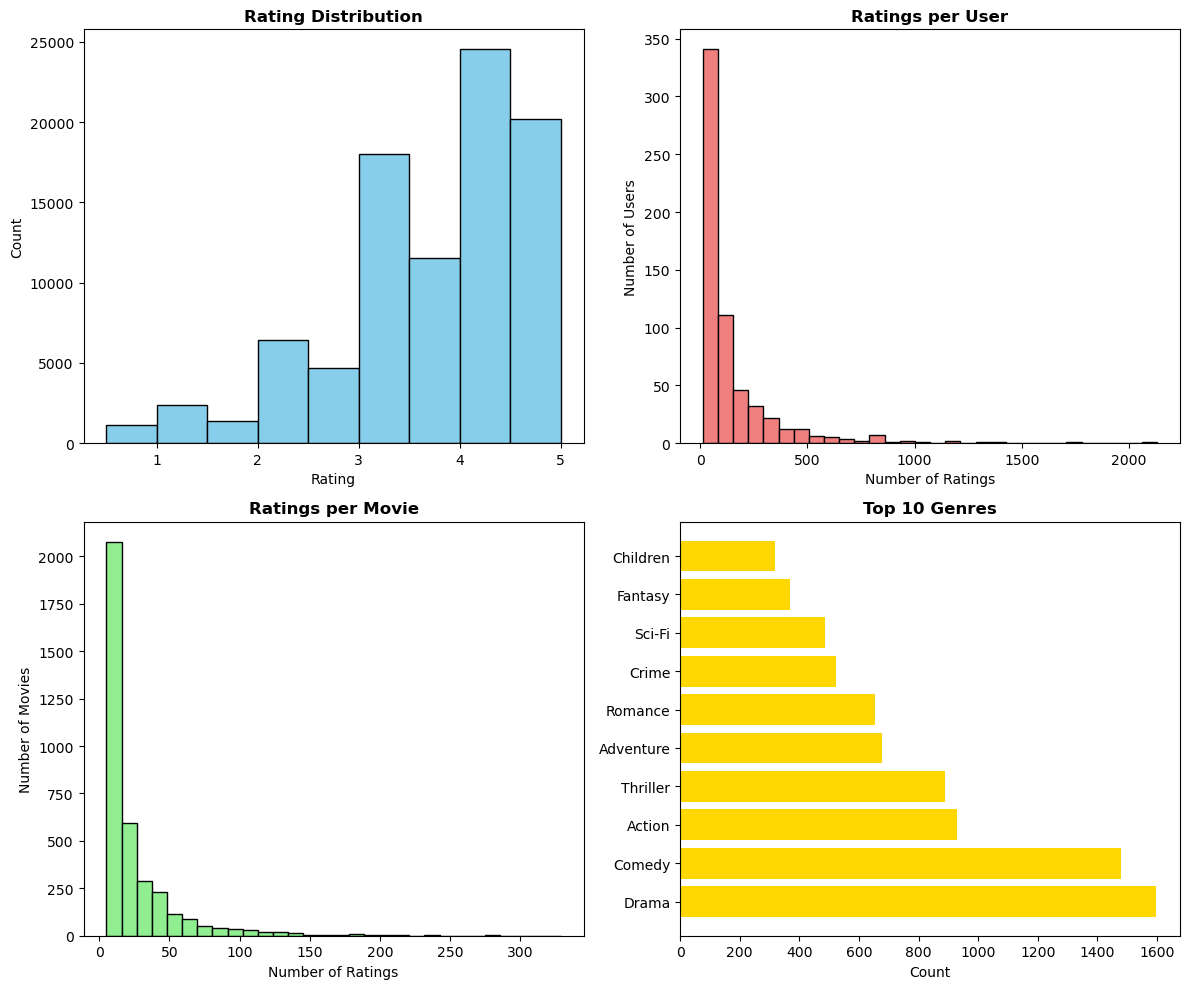

EDA visualizations saved to 'visualizations/eda_plots.png'


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Rating distribution
axes[0, 0].hist(ratings['rating'], bins=9, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Rating Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Rating')
axes[0, 0].set_ylabel('Count')

# Ratings per user
user_rating_counts = ratings.groupby('user_id').size()
axes[0, 1].hist(user_rating_counts, bins=30, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Ratings per User', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Number of Ratings')
axes[0, 1].set_ylabel('Number of Users')

# Ratings per movie
movie_rating_counts = ratings.groupby('movie_id').size()
axes[1, 0].hist(movie_rating_counts, bins=30, color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Ratings per Movie', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Number of Ratings')
axes[1, 0].set_ylabel('Number of Movies')

# Top genres
all_genres = movies['genres'].str.split('|').explode()
genre_counts = all_genres.value_counts().head(10)
axes[1, 1].barh(genre_counts.index, genre_counts.values, color='gold')
axes[1, 1].set_title('Top 10 Genres', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('visualizations/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print("EDA visualizations saved to 'visualizations/eda_plots.png'")

In [12]:
train_ratings, test_ratings = train_test_split(
    ratings, test_size=0.2, random_state=42, stratify=ratings['user_id']
)

print("Train size:", len(train_ratings), "(" + str(round(len(train_ratings)/len(ratings)*100, 1)) + "%)")
print("Test size:", len(test_ratings), "(" + str(round(len(test_ratings)/len(ratings)*100, 1)) + "%)")
print("Train users:", train_ratings['user_id'].nunique())
print("Test users:", test_ratings['user_id'].nunique())

Train size: 72219 (80.0%)
Test size: 18055 (20.0%)
Train users: 610
Test users: 610


**------ 2. Content-Based Filtering Module: ------**

In [13]:
# Create TF-IDF matrix --> convert trext to vector form
tfidf = TfidfVectorizer(stop_words='english', max_features=500, ngram_range=(1, 2))
tfidf_matrix = tfidf.fit_transform(movies['genres_text'])

# Calculate cosine similarity
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)
print("Cosine Similarity Shape:", cosine_sim.shape)
print("Number of unique terms:", len(tfidf.get_feature_names_out()))

# Create indices mapping for movie titles
# returns a Series where the index is the cleaned movie title and the value is the original index of that movie in the DataFrame
indices = pd.Series(movies.index, index=movies['title_clean']).drop_duplicates()

# Save models
joblib.dump(tfidf, "models/tfidf.pkl")
joblib.dump(tfidf_matrix, "models/tfidf_matrix.pkl")
joblib.dump(cosine_sim, "models/cosine_sim.pkl")
joblib.dump(movies, "models/movies_processed.pkl")
joblib.dump(indices, "models/indices.pkl")

print("Content-based models saved!")

TF-IDF Matrix Shape: (3650, 159)
Cosine Similarity Shape: (3650, 3650)
Number of unique terms: 159
Content-based models saved!


**Generate recommendations based on item similarity**


In [14]:
# check if title exists in indices, if not try to find a close match
def content_recommendations(title, top_n=10):
    """Recommend movies similar to a given movie based on genres"""
    if title not in indices.index:
        matching_titles = indices.index[indices.index.str.contains(title, case=False)]
        if len(matching_titles) == 0:
            print("Movie '" + title + "' not found!")
            return pd.DataFrame()
        title = matching_titles[0]
        print("   Found matching: '" + title + "'")
    
    # Get the index of the movie that matches the title
    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    # lambda like key and value function to sort by similarity score
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n+1]
    movie_indices = [i[0] for i in sim_scores]
    
    results = movies.iloc[movie_indices][['movie_id', 'title_clean', 'genres']].copy()
    results = results.rename(columns={'title_clean': 'title'})
    results['similarity_score'] = [i[1] for i in sim_scores]
    return results

print("Content-Based Recommendations (Similar to 'Toy Story'):")
result = content_recommendations("Toy Story", 5)
if len(result) > 0:
    for i, row in result.iterrows():
        print(str(i+1) + ". " + row['title'] + " (Similarity: " + str(round(row['similarity_score'], 3)) + ")")

Content-Based Recommendations (Similar to 'Toy Story'):
1156. Antz (Similarity: 1.0)
1546. Toy Story 2 (Similarity: 1.0)
1792. Adventures of Rocky and Bullwinkle, The (Similarity: 1.0)
1884. Emperor's New Groove, The (Similarity: 1.0)
2079. Monsters, Inc. (Similarity: 1.0)


**------ 3. Collaborative Filtering Module: ------**

In [17]:
# Prepare data for Surprise library
# we start from 1 because the library does not read the decimal number like 0.5
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(train_ratings[['user_id', 'movie_id', 'rating']], reader)

# Train-test split for surprise
# surprise check if model can predict the ratings of the test set based on the training set
trainset, testset = surprise_split(data, test_size=0.2, random_state=42)

print("Trainset Size:", "{:,}".format(trainset.n_ratings), "ratings")
print("Testset Size:", "{:,}".format(len(testset)), "ratings")
print("Users in trainset:", trainset.n_users)
print("Movies in trainset:", trainset.n_items)
# Sparsity is calculated as the percentage of missing ratings in the user-item matrix
print("Sparsity:", round((1 - trainset.n_ratings / (trainset.n_users * trainset.n_items)) * 100, 2), "%")

Trainset Size: 57,775 ratings
Testset Size: 14,444 ratings
Users in trainset: 610
Movies in trainset: 3646
Sparsity: 97.4 %


**Collaborative Filtering Module - Train Singular Value Decomposition (SVD) model**

In [18]:
# min matrix to check if the model can predict the ratings of the test set based on the training set
# Initialize and train SVD with optimized parameters
svd_model = SVD(n_factors=100, n_epochs=30, lr_all=0.005, reg_all=0.02, random_state=42)
svd_model.fit(trainset)

# Predict on test set
predictions = svd_model.test(testset)

# Save model
joblib.dump(svd_model, "models/svd_model.pkl")

print("SVD model trained and saved!")
print("\nModel Information:")
print("   Type:", type(svd_model).__name__)
print("   n_factors:", svd_model.n_factors)
print("   n_epochs:", svd_model.n_epochs)

SVD model trained and saved!

Model Information:
   Type: SVD
   n_factors: 100
   n_epochs: 30


**COLLABORATIVE MODEL EVALUATION**

In [19]:
# Calculate Root Mean Square Error (RMSE) and Mean Absolute Error (MAE)
cf_rmse = rmse(predictions, verbose=False)
cf_mae = mae(predictions, verbose=False)

print("Collaborative Filtering (SVD) Results:")
print("   RMSE:", round(cf_rmse, 4))
print("   MAE:", round(cf_mae, 4))

# Get actual and predicted ratings
true_ratings = [pred.r_ui for pred in predictions]
pred_ratings = [pred.est for pred in predictions]

# Binary classification metrics
# convert ratings to binary based on a threshold (e.g., 4 and above is considered positive)
threshold = 4
true_binary = [1 if r >= threshold else 0 for r in true_ratings]
pred_binary = [1 if p >= threshold else 0 for p in pred_ratings]

cf_precision = precision_score(true_binary, pred_binary, zero_division=0)
cf_recall = recall_score(true_binary, pred_binary, zero_division=0)
cf_f1 = f1_score(true_binary, pred_binary, zero_division=0)

print("\nClassification Metrics (threshold = " + str(threshold) + "):")
print("   Precision:", round(cf_precision, 4))
print("   Recall:", round(cf_recall, 4))
print("   F1-Score:", round(cf_f1, 4))

Collaborative Filtering (SVD) Results:
   RMSE: 0.8678
   MAE: 0.6647

Classification Metrics (threshold = 4):
   Precision: 0.8085
   Recall: 0.3671
   F1-Score: 0.5049


**Collaborative Filtering Module - Generate recommendations**

In [20]:
def collaborative_recommendations(user_id, top_n=10):
    """Get collaborative filtering recommendations for a user"""
    movie_ids = movies['movie_id'].unique()
    watched_movies = ratings[ratings['user_id'] == user_id]['movie_id'].values
    unseen_movies = [movie for movie in movie_ids if movie not in watched_movies]
    
    print("User " + str(user_id) + ": " + str(len(watched_movies)) + " watched, " + str(len(unseen_movies)) + " unseen")
    
    predictions_list = []
    for movie_id in unseen_movies:
        pred = svd_model.predict(user_id, movie_id)
        predictions_list.append((movie_id, pred.est))
    
    predictions_list.sort(key=lambda x: x[1], reverse=True)
    top_predictions = predictions_list[:top_n]
    
    recommendations = []
    for movie_id, score in top_predictions:
        title = movies[movies['movie_id'] == movie_id]['title_clean'].values[0]
        recommendations.append([title, round(score, 2)])
    
    return pd.DataFrame(recommendations, columns=['Movie', 'Predicted Rating'])

print("Collaborative Recommendations for User 1:")
result = collaborative_recommendations(1, 5)
if len(result) > 0:
    print(result.to_string(index=False))

Collaborative Recommendations for User 1:
User 1: 227 watched, 3423 unseen
                    Movie  Predicted Rating
Shawshank Redemption, The                 5
            Trainspotting                 5
             Sunset Blvd.                 5
             Mary Poppins                 5
          Cinema Paradiso                 5


**------ 4. Hybrid Recommendation Engine: ------**

In [21]:
def hybrid_recommendation(user_id, favorite_movie, alpha=0.7, top_n=10):
    """Hybrid recommendation combining content-based and collaborative filtering"""
    if favorite_movie not in indices.index:
        matching = indices.index[indices.index.str.contains(favorite_movie, case=False)]
        if len(matching) == 0:
            print("Movie '" + favorite_movie + "' not found!")
            return pd.DataFrame()
        favorite_movie = matching[0]
        print("   Using: '" + favorite_movie + "'")
    
    # Content-based part
    idx = indices[favorite_movie]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:50]
    
    content_df = pd.DataFrame(sim_scores, columns=['index', 'content_score'])
    content_df['movie_id'] = content_df['index'].apply(lambda x: movies.iloc[x]['movie_id'])
    
    # Collaborative part
    collab_scores = []
    for movie_id in content_df['movie_id']:
        pred = svd_model.predict(user_id, movie_id)
        collab_scores.append(pred.est)
    content_df['collab_score'] = collab_scores
    
    # Normalize scores
    scaler = MinMaxScaler()
    content_df[['content_score', 'collab_score']] = scaler.fit_transform(content_df[['content_score', 'collab_score']])
    
    # Hybrid score
    content_df['hybrid_score'] = alpha * content_df['collab_score'] + (1 - alpha) * content_df['content_score']
    content_df = content_df.sort_values('hybrid_score', ascending=False)
    
    # Prepare results
    recommendations = []
    for _, row in content_df.head(top_n).iterrows():
        movie_title = movies[movies['movie_id'] == row['movie_id']]['title_clean'].values[0]
        recommendations.append([movie_title, round(row['hybrid_score'], 3)])
    
    return pd.DataFrame(recommendations, columns=['Movie', 'Hybrid Score'])

print("Hybrid Recommendations (User 1 + Toy Story, alpha=0.7):")
result = hybrid_recommendation(1, "Toy Story", alpha=0.7, top_n=10)
if len(result) > 0:
    for i, row in result.iterrows():
        print(str(i+1) + ". " + row['Movie'] + " (Score: " + str(row['Hybrid Score']) + ")")

Hybrid Recommendations (User 1 + Toy Story, alpha=0.7):
1. Toy Story 2 (Score: 1.0)
2. Monsters, Inc. (Score: 0.835)
3. Shrek (Score: 0.748)
4. Finding Nemo (Score: 0.666)
5. Home (Score: 0.666)
6. Ice Age (Score: 0.617)
7. Moana (Score: 0.606)
8. The Lego Movie (Score: 0.58)
9. Fantastic Mr. Fox (Score: 0.576)
10. Emperor's New Groove, The (Score: 0.57)


In [22]:
def get_cb_score_advanced(user_id, movie_id):
    """Advanced content-based score using weighted similarity"""
    movie_idx = movies[movies['movie_id'] == movie_id].index
    if len(movie_idx) == 0:
        return 3.0
    movie_idx = movie_idx[0]
    
    user_ratings = ratings[ratings['user_id'] == user_id]
    user_top = user_ratings.sort_values('rating', ascending=False).head(10)
    
    if len(user_top) == 0:
        return 3.0
    
    weighted_sim = 0
    total_weight = 0
    
    for _, row in user_top.iterrows():
        top_idx = movies[movies['movie_id'] == row['movie_id']].index
        if len(top_idx) > 0:
            top_idx = top_idx[0]
            sim = cosine_sim[movie_idx, top_idx]
            weight = (row['rating'] - 1) / 4
            weighted_sim += sim * weight
            total_weight += weight
    
    if total_weight > 0:
        cb_score = weighted_sim / total_weight
        cb_score = 1 + cb_score * 4
        return max(1.0, min(5.0, cb_score))
    return 3.0

def evaluate_hybrid_advanced(alpha=0.7, sample_size=None):
    """Advanced hybrid model evaluation"""
    actuals = []
    predictions_list = []
    test_data = test_ratings if sample_size is None else test_ratings.head(sample_size)
    
    for _, row in test_data.iterrows():
        user_id = row['user_id']
        movie_id = row['movie_id']
        actual = row['rating']
        
        cf_pred = svd_model.predict(user_id, movie_id).est
        cb_pred = get_cb_score_advanced(user_id, movie_id)
        hybrid_pred = alpha * cf_pred + (1 - alpha) * cb_pred
        hybrid_pred = max(1.0, min(5.0, hybrid_pred))
        
        actuals.append(actual)
        predictions_list.append(hybrid_pred)
    
    rmse_hybrid = np.sqrt(mean_squared_error(actuals, predictions_list))
    mae_hybrid = mean_absolute_error(actuals, predictions_list)
    
    actual_binary = [1 if a >= 4 else 0 for a in actuals]
    pred_binary = [1 if p >= 4 else 0 for p in predictions_list]
    
    return {
        'rmse': rmse_hybrid,
        'mae': mae_hybrid,
        'precision': precision_score(actual_binary, pred_binary, zero_division=0),
        'recall': recall_score(actual_binary, pred_binary, zero_division=0),
        'f1': f1_score(actual_binary, pred_binary, zero_division=0),
        'samples': len(actuals)
    }

print("Evaluating hybrid model on test set...")
hybrid_metrics = evaluate_hybrid_advanced(alpha=0.7)

print("\nHybrid Model Results (alpha=0.7):")
print("   Samples evaluated:", "{:,}".format(hybrid_metrics['samples']))
print("   RMSE:", round(hybrid_metrics['rmse'], 4))
print("   MAE:", round(hybrid_metrics['mae'], 4))
print("   Precision:", round(hybrid_metrics['precision'], 4))
print("   Recall:", round(hybrid_metrics['recall'], 4))
print("   F1-Score:", round(hybrid_metrics['f1'], 4))

Evaluating hybrid model on test set...

Hybrid Model Results (alpha=0.7):
   Samples evaluated: 18,055
   RMSE: 1.0442
   MAE: 0.8742
   Precision: 0.9559
   Recall: 0.0072
   F1-Score: 0.0144


**------ 6. Evaluation Metrics: ------**

In [23]:
comparison = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'Precision', 'Recall', 'F1-Score'],
    'Collaborative (SVD)': [cf_rmse, cf_mae, cf_precision, cf_recall, cf_f1],
    'Hybrid (alpha=0.7)': [hybrid_metrics['rmse'], hybrid_metrics['mae'], 
                            hybrid_metrics['precision'], hybrid_metrics['recall'], hybrid_metrics['f1']]
})

comparison['Improvement'] = comparison['Collaborative (SVD)'] - comparison['Hybrid (alpha=0.7)']

for metric in ['RMSE', 'MAE']:
    idx = comparison[comparison['Metric'] == metric].index[0]
    if comparison.loc[idx, 'Improvement'] > 0:
        comparison.loc[idx, 'Status'] = 'Hybrid Better'
    else:
        comparison.loc[idx, 'Status'] = 'Collaborative Better'

for metric in ['Precision', 'Recall', 'F1-Score']:
    idx = comparison[comparison['Metric'] == metric].index[0]
    if comparison.loc[idx, 'Improvement'] > 0:
        comparison.loc[idx, 'Status'] = 'Hybrid Better'
    else:
        comparison.loc[idx, 'Status'] = 'Collaborative Better'

print(comparison.to_string(index=False))

hybrid_wins = sum(comparison['Status'].str.contains('Hybrid Better'))
total = len(comparison)
print("\nVerdict: Hybrid model wins on " + str(hybrid_wins) + "/" + str(total) + " metrics")

   Metric  Collaborative (SVD)  Hybrid (alpha=0.7)  Improvement               Status
     RMSE             0.867785            1.044152    -0.176367 Collaborative Better
      MAE             0.664697            0.874175    -0.209478 Collaborative Better
Precision             0.808465            0.955882    -0.147417 Collaborative Better
   Recall             0.367068            0.007247     0.359820        Hybrid Better
 F1-Score             0.504897            0.014385     0.490512        Hybrid Better

Verdict: Hybrid model wins on 2/5 metrics


**Hybrid Recommendation Engine - Optimize alpha**

In [24]:
alpha_values = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
alpha_results = {}

print("Testing different alpha values...")
for alpha in alpha_values:
    results = evaluate_hybrid_advanced(alpha=alpha, sample_size=500)
    alpha_results[alpha] = results
    print("   alpha=" + str(alpha) + ": RMSE=" + str(round(results['rmse'], 4)) + ", F1=" + str(round(results['f1'], 4)))

best_alpha = min(alpha_results, key=lambda x: alpha_results[x]['rmse'])
best_f1_alpha = max(alpha_results, key=lambda x: alpha_results[x]['f1'])

print("\nBest alpha for RMSE:", best_alpha)
print("Best alpha for F1:", best_f1_alpha)
print("Recommended alpha:", best_alpha)

Testing different alpha values...
   alpha=0.0: RMSE=2.2902, F1=0.0
   alpha=0.1: RMSE=2.0933, F1=0.0
   alpha=0.3: RMSE=1.7114, F1=0.0
   alpha=0.5: RMSE=1.3564, F1=0.0
   alpha=0.7: RMSE=1.0557, F1=0.0304
   alpha=0.9: RMSE=0.8678, F1=0.3023
   alpha=1.0: RMSE=0.842, F1=0.5105

Best alpha for RMSE: 1.0
Best alpha for F1: 1.0
Recommended alpha: 1.0


**Evaluation Metrics - Visualize results**

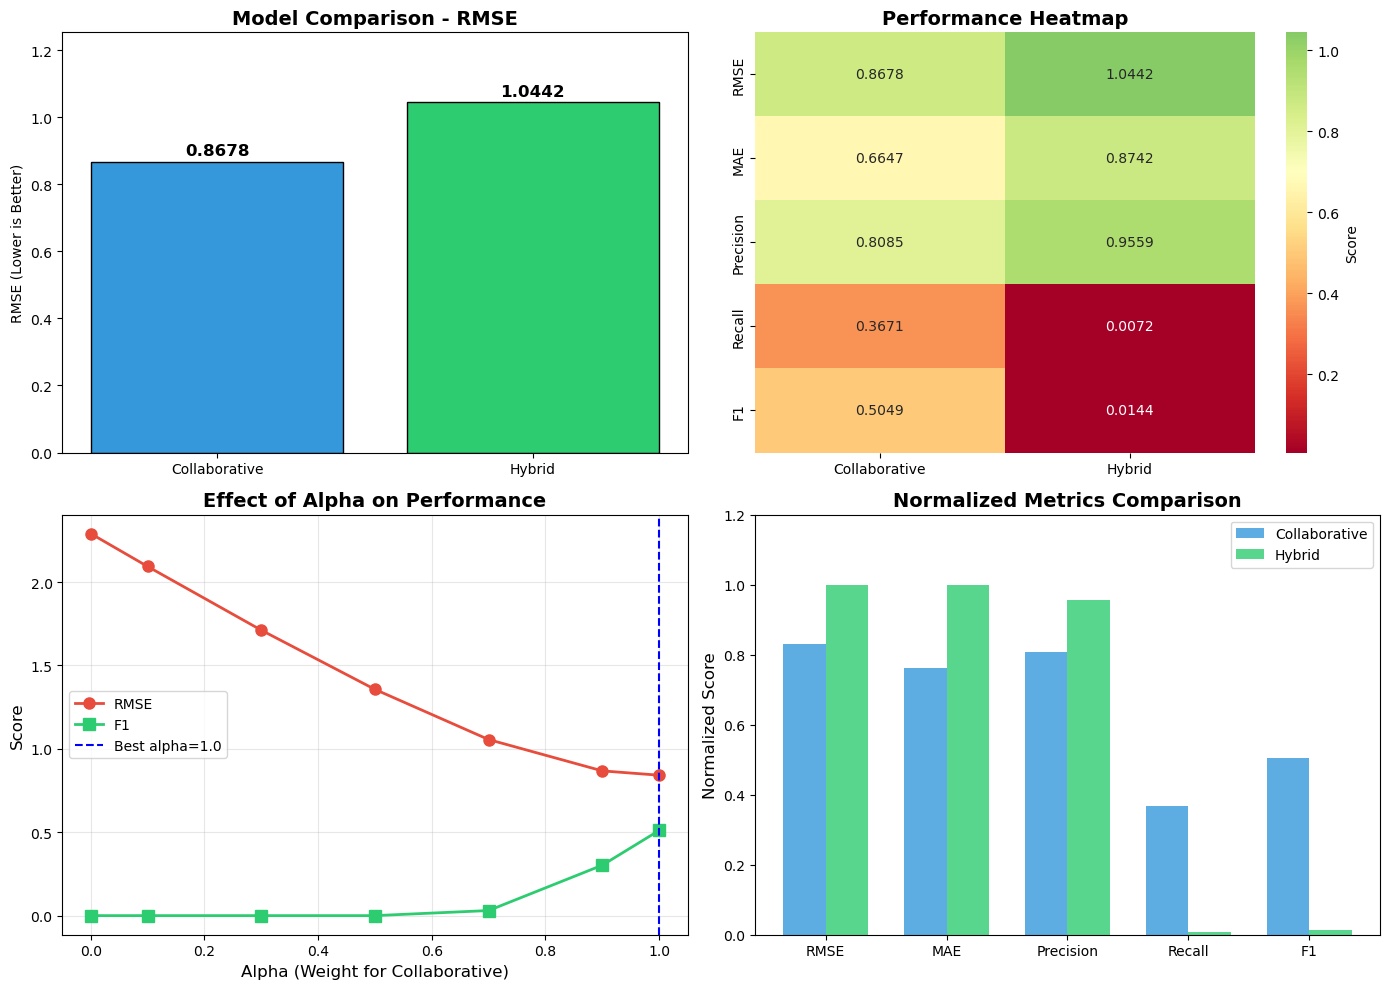

Visualizations saved to 'visualizations/comprehensive_comparison.png'


In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. RMSE Comparison
models = ['Collaborative', 'Hybrid']
rmse_scores = [cf_rmse, hybrid_metrics['rmse']]
colors = ['#3498db', '#2ecc71']

bars = axes[0, 0].bar(models, rmse_scores, color=colors, edgecolor='black')
axes[0, 0].set_title('Model Comparison - RMSE', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('RMSE (Lower is Better)')
axes[0, 0].set_ylim(0, max(rmse_scores) * 1.2)

for bar, score in zip(bars, rmse_scores):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                    str(round(score, 4)), ha='center', fontweight='bold', fontsize=12)

# 2. Performance Heatmap
metrics_df = pd.DataFrame({
    'Collaborative': [cf_rmse, cf_mae, cf_precision, cf_recall, cf_f1],
    'Hybrid': [hybrid_metrics['rmse'], hybrid_metrics['mae'], 
               hybrid_metrics['precision'], hybrid_metrics['recall'], hybrid_metrics['f1']]
}, index=['RMSE', 'MAE', 'Precision', 'Recall', 'F1'])

sns.heatmap(metrics_df, annot=True, fmt='.4f', cmap='RdYlGn', 
            center=0.7, ax=axes[0, 1], cbar_kws={'label': 'Score'})
axes[0, 1].set_title('Performance Heatmap', fontsize=14, fontweight='bold')

# 3. Effect of Alpha
alphas = list(alpha_results.keys())
alpha_rmse = [alpha_results[a]['rmse'] for a in alphas]
alpha_f1 = [alpha_results[a]['f1'] for a in alphas]

axes[1, 0].plot(alphas, alpha_rmse, 'o-', color='#e74c3c', linewidth=2, markersize=8, label='RMSE')
axes[1, 0].plot(alphas, alpha_f1, 's-', color='#2ecc71', linewidth=2, markersize=8, label='F1')
axes[1, 0].axvline(x=best_alpha, color='blue', linestyle='--', label='Best alpha=' + str(best_alpha))
axes[1, 0].set_xlabel('Alpha (Weight for Collaborative)', fontsize=12)
axes[1, 0].set_ylabel('Score', fontsize=12)
axes[1, 0].set_title('Effect of Alpha on Performance', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Normalized Metrics Bar Chart
metrics = ['RMSE', 'MAE', 'Precision', 'Recall', 'F1']
x = np.arange(len(metrics))
width = 0.35

collab_norm = [cf_rmse/max(rmse_scores), cf_mae/hybrid_metrics['mae'], 
               cf_precision, cf_recall, cf_f1]
hybrid_norm = [hybrid_metrics['rmse']/max(rmse_scores), 1, 
               hybrid_metrics['precision'], hybrid_metrics['recall'], hybrid_metrics['f1']]

axes[1, 1].bar(x - width/2, collab_norm, width, label='Collaborative', color='#3498db', alpha=0.8)
axes[1, 1].bar(x + width/2, hybrid_norm, width, label='Hybrid', color='#2ecc71', alpha=0.8)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(metrics)
axes[1, 1].set_ylabel('Normalized Score', fontsize=12)
axes[1, 1].set_title('Normalized Metrics Comparison', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].set_ylim(0, 1.2)

plt.tight_layout()
plt.savefig('visualizations/comprehensive_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Visualizations saved to 'visualizations/comprehensive_comparison.png'")

**Data Processing Scripts - Export results to CSV**

In [26]:
# Get recommendations
hybrid_results = hybrid_recommendation(1, "Toy Story", alpha=best_alpha, top_n=10)

if len(hybrid_results) > 0:
    hybrid_results.to_csv("outputs/hybrid_recommendations.csv", index=False)
    print("Saved: outputs/hybrid_recommendations.csv")

# Save evaluation metrics
evaluation_df = pd.DataFrame({
    "Model": ["Collaborative"] * 5 + ["Hybrid"] * 5,
    "Metric": ["RMSE", "MAE", "Precision", "Recall", "F1"] * 2,
    "Value": [cf_rmse, cf_mae, cf_precision, cf_recall, cf_f1,
              hybrid_metrics['rmse'], hybrid_metrics['mae'], 
              hybrid_metrics['precision'], hybrid_metrics['recall'], hybrid_metrics['f1']]
})

evaluation_df.to_csv("outputs/evaluation_results.csv", index=False)
print("Saved: outputs/evaluation_results.csv")

# Alpha optimization results
alpha_df = pd.DataFrame([{
    'alpha': alpha,
    'rmse': alpha_results[alpha]['rmse'],
    'f1': alpha_results[alpha]['f1']
} for alpha in alpha_results])
alpha_df.to_csv("outputs/alpha_optimization.csv", index=False)
print("Saved: outputs/alpha_optimization.csv")

print("\nAll results exported successfully!")

Saved: outputs/hybrid_recommendations.csv
Saved: outputs/evaluation_results.csv
Saved: outputs/alpha_optimization.csv

All results exported successfully!
